In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('insurance_claim_updated.csv')

In [ ]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital.gains', 'capital.loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported'],
      dtype='object')

In [ ]:
#change date from object to datetime
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'],errors='coerce')
#df['incident_date'] = pd.to_datetime(df['incident_date'],format='Mixed')
df['incident_date'] = pd.to_datetime(df['incident_date'], dayfirst=True, errors='coerce')

<ipython-input-4-c90ce2805ed3>:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'],errors='coerce')


In [ ]:
#check null/nan values
df.isna().sum().sort_values(ascending=False)

,0
authorities_contacted,707
witnesses,0
incident_state,0
incident_city,0
incident_location,0
incident_hour_of_the_day,0
number_of_vehicles_involved,0
property_damage,0
bodily_injuries,0
months_as_customer,0


In [ ]:
print(df['authorities_contacted'].unique())

['Other' nan 'Police' 'Fire' 'Ambulance']


In [ ]:
# handling nan value in authorities_contacted
df['authorities_contacted'].fillna("NO", inplace=True)

<ipython-input-7-561927bb1a8b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['authorities_contacted'].fillna("NO", inplace=True)


In [ ]:
#check unique values for all coulmns and inconsistent values
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())  # Shows all unique values
    print("-" * 40)

Column: months_as_customer
[  5 462 198 384 100 306 105 249  44 104 173 135 176  79 169  89  85   9
 150 134  11 319  10 423 330 371 401  16 273 275 217 136 232 357 345  12
  75 458  90 392 592 262 258 231 128 189 212 154 146  22 284 112 300 172
 247 124  97 343 317 651 333   1 551  61 463 288 560  70 441 113  27 338
 280 238 188 434 289 307 132 310 140  63 207 524 248 325 506 234 457 304
  68 634 265 267 385 424 364 359 303 139 478 279 148 425  74 283 285 410
  94 351  78 142 205  49 242 407 201  40 180 391 507 293  13 214 396 138
 147  98 430 145 448 340 261  66 237 175 486 192  62 143  58 159 178 226
 122 174 296 408 133 420 313 246 230 454 272  48 199 193 439  95 259 115
 274  69 118 220 255  87 320   3 584 213  15 257  19 368 491  38 194 504
 129 223 197 120 131 271 206 153 208 332 276 161  54  72 568 369 240  17
 538  60 202 361  84 294  53 183  50 167  33 200  39 209 312  34 414 316
  93 103 141 256 177 245 186 218  23 107 254 321 510 335 170 236  92  20
 365  41 402 191  91 227

In [ ]:
# handling inconsistency// ? in collision_type,property_damage,police_report_available
df['collision_type'].replace("?", "Unknown", inplace=True)
df['property_damage'].replace("?", "Unknown", inplace=True)
df['police_report_available'].replace("?", "Unknown", inplace=True)

<ipython-input-9-b2bc1a48afd7>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['collision_type'].replace("?", "Unknown", inplace=True)
<ipython-input-9-b2bc1a48afd7>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
print(df['collision_type'].unique())
print(df['property_damage'].unique())
print(df['police_report_available'].unique())

['Front Collision' 'Rear Collision' 'Unknown' 'Side Collision']
['Unknown' 'NO' 'YES']
['YES' 'Unknown' 'NO']


In [ ]:
#check duplicated rows
print(f"Duplicate Rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)  # Remove if needed

Duplicate Rows: 0


In [ ]:
# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
# Function to cap outliers using IQR method

def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# List of numerical columns with visible outliers
outlier_cols = ['policy_annual_premium', 'umbrella_limit', 'capital.gains', 'capital.loss',
                'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim']

# Apply outlier capping
for col in outlier_cols:
    df = cap_outliers(df, col)

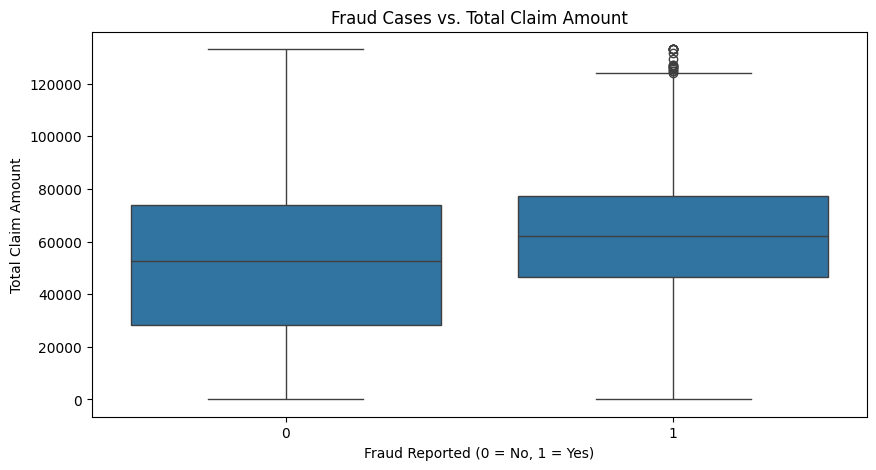

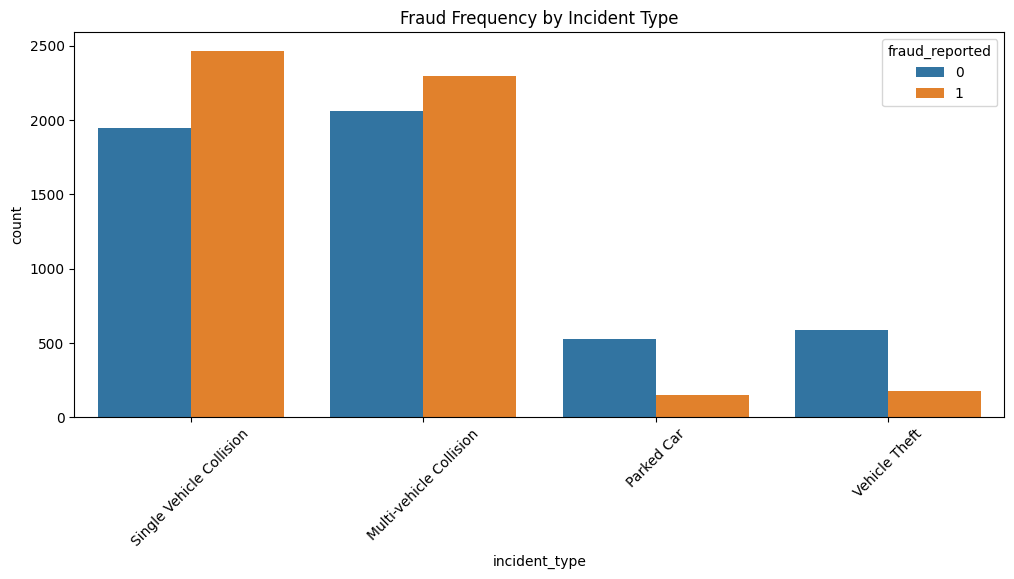

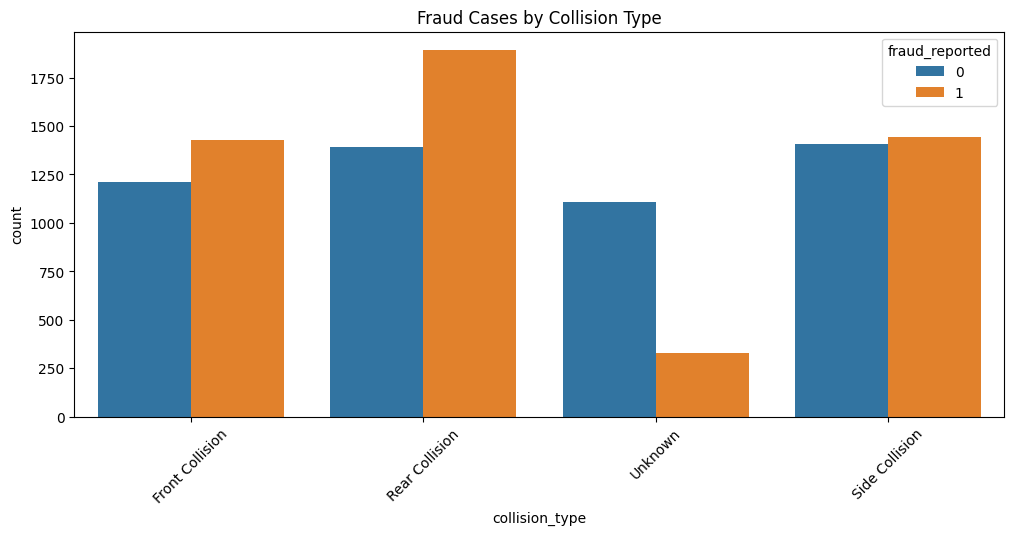

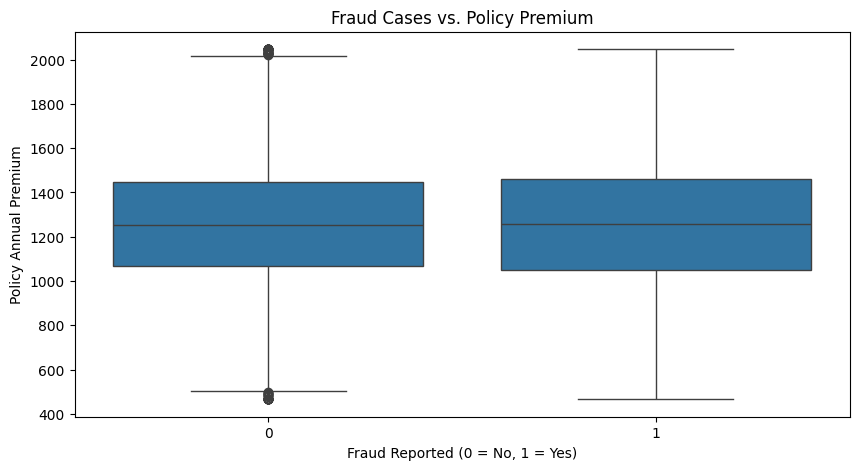

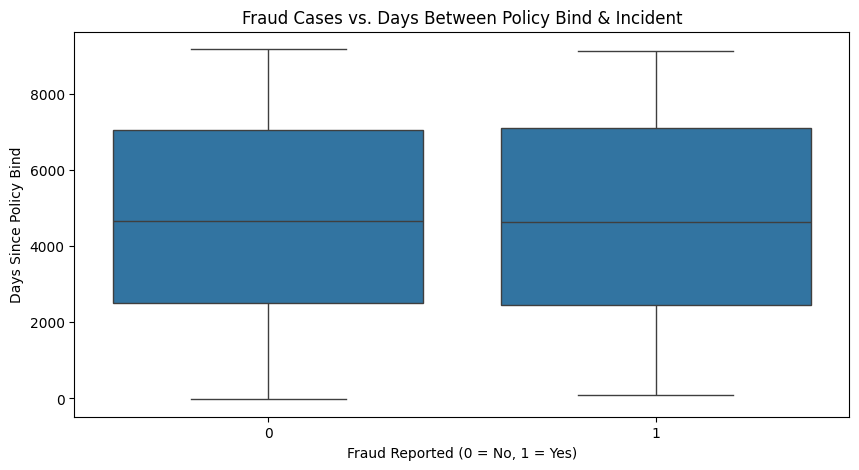

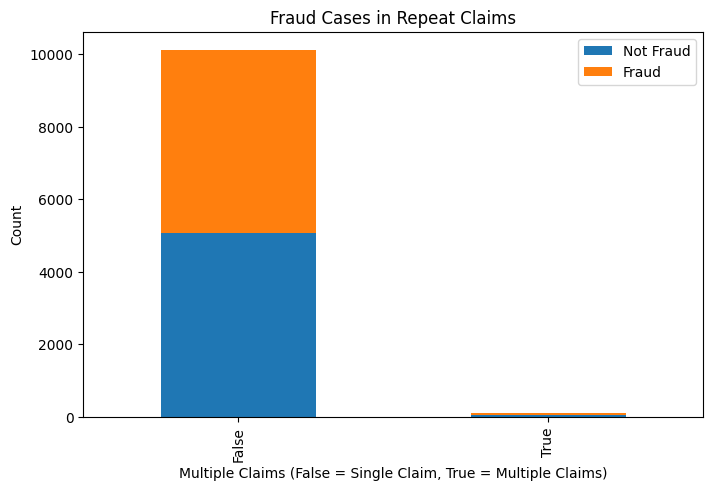

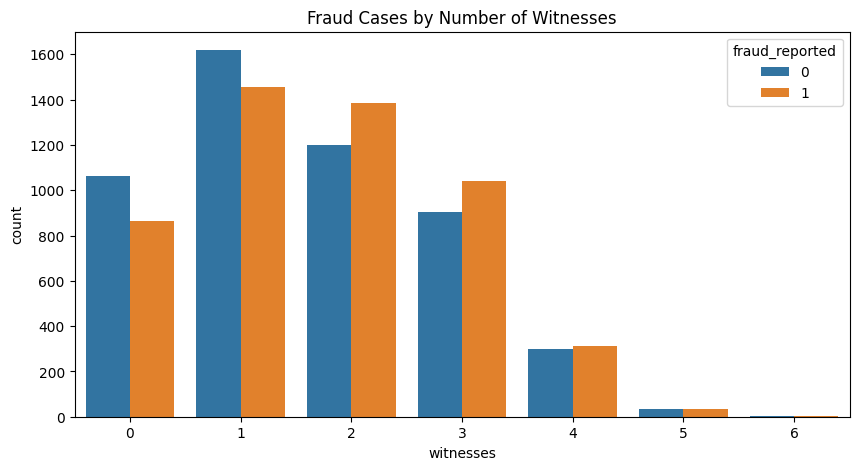

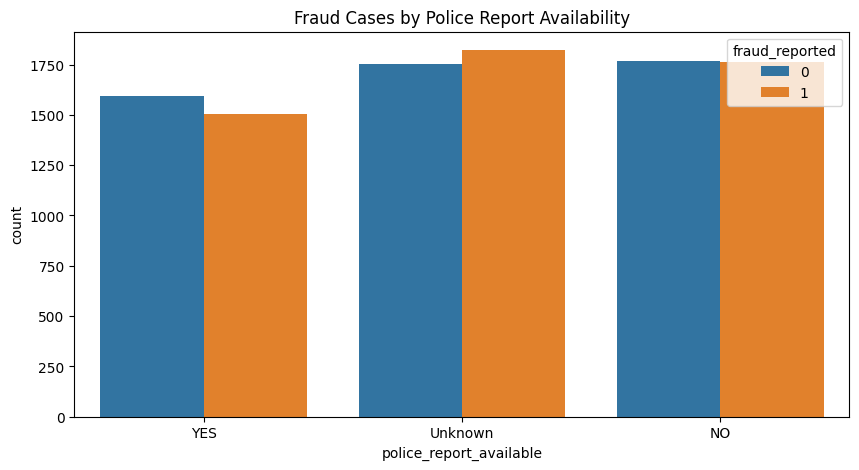

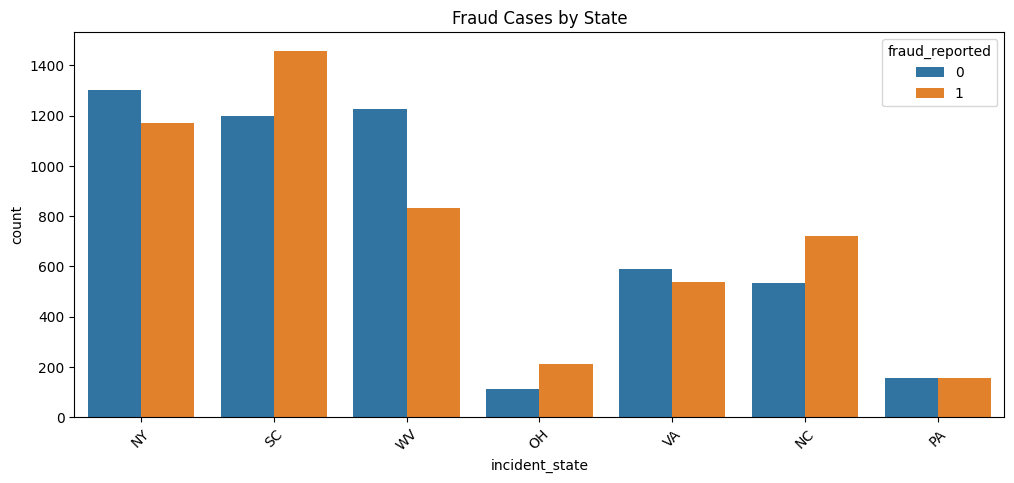

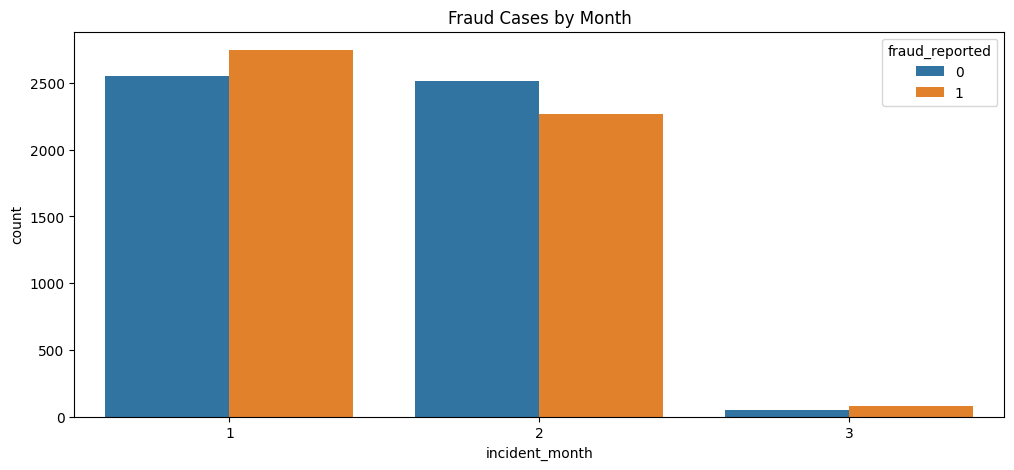

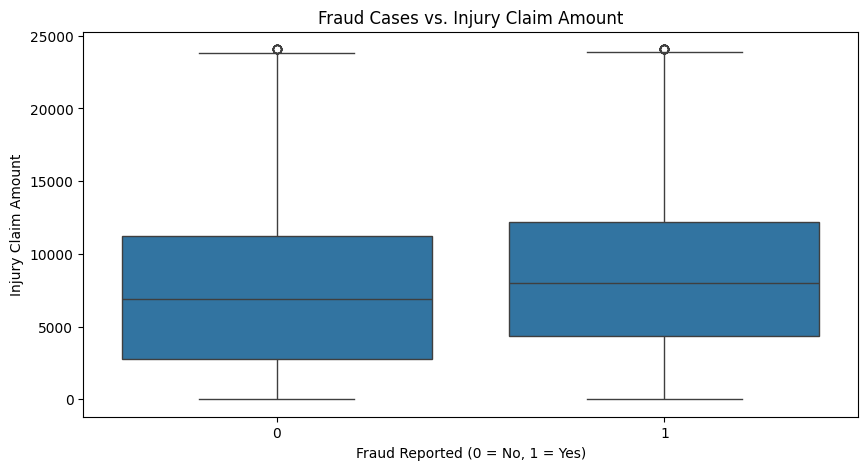

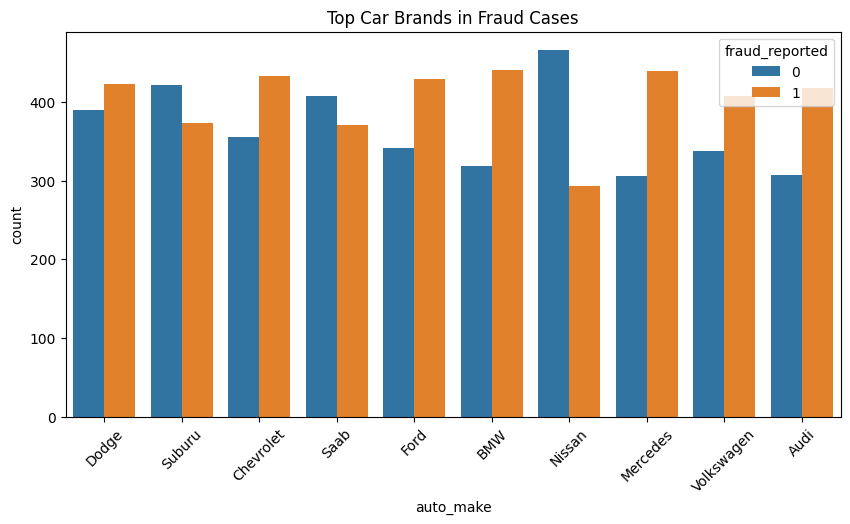

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

# Convert fraud column to binary (0 for No, 1 for Yes)
df['fraud_reported'] = df['fraud_reported'].map({'Y': 1, 'N': 0})

### 1️⃣ Fraud vs. Claim Amount
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['fraud_reported'], y=df['total_claim_amount'])
plt.title("Fraud Cases vs. Total Claim Amount")
plt.xlabel("Fraud Reported (0 = No, 1 = Yes)")
plt.ylabel("Total Claim Amount")
plt.show()

### 2️⃣ Incident & Collision Type Analysis
plt.figure(figsize=(12, 5))
sns.countplot(x=df['incident_type'], hue=df['fraud_reported'])
plt.title("Fraud Frequency by Incident Type")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(x=df['collision_type'], hue=df['fraud_reported'])
plt.title("Fraud Cases by Collision Type")
plt.xticks(rotation=45)
plt.show()

### 3️⃣ Policyholder Behavior (Premium, Timing, Duration)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['fraud_reported'], y=df['policy_annual_premium'])
plt.title("Fraud Cases vs. Policy Premium")
plt.xlabel("Fraud Reported (0 = No, 1 = Yes)")
plt.ylabel("Policy Annual Premium")
plt.show()

# Calculate days between policy bind and incident
#change date from object to datetime
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'],errors='coerce')
#df['incident_date'] = pd.to_datetime(df['incident_date'],format='Mixed')
df['incident_date'] = pd.to_datetime(df['incident_date'], dayfirst=True, errors='coerce')
df['days_since_policy_bind'] = (df['incident_date'] - df['policy_bind_date']).dt.days

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['fraud_reported'], y=df['days_since_policy_bind'])
plt.title("Fraud Cases vs. Days Between Policy Bind & Incident")
plt.xlabel("Fraud Reported (0 = No, 1 = Yes)")
plt.ylabel("Days Since Policy Bind")
plt.show()

### 4️⃣ Claim History (Repeat Offenders?)
df['multiple_claims'] = df.duplicated(subset=['policy_number'], keep=False)
fraud_repeat_claims = df.groupby(['multiple_claims', 'fraud_reported'])['fraud_reported'].count().unstack()
fraud_repeat_claims.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Fraud Cases in Repeat Claims")
plt.xlabel("Multiple Claims (False = Single Claim, True = Multiple Claims)")
plt.ylabel("Count")
plt.legend(["Not Fraud", "Fraud"])
plt.show()

### 5️⃣ Witness & Police Report Analysis
plt.figure(figsize=(10, 5))
sns.countplot(x=df['witnesses'], hue=df['fraud_reported'])
plt.title("Fraud Cases by Number of Witnesses")
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x=df['police_report_available'], hue=df['fraud_reported'])
plt.title("Fraud Cases by Police Report Availability")
plt.show()

### 6️⃣ Geographic & Seasonal Trends
plt.figure(figsize=(12, 5))
sns.countplot(x=df['incident_state'], hue=df['fraud_reported'])
plt.title("Fraud Cases by State")
plt.xticks(rotation=45)
plt.show()

df['incident_month'] = df['incident_date'].dt.month
plt.figure(figsize=(12, 5))
sns.countplot(x=df['incident_month'], hue=df['fraud_reported'])
plt.title("Fraud Cases by Month")
plt.show()

### 7️⃣ Vehicle & Injury Claims
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['fraud_reported'], y=df['injury_claim'])
plt.title("Fraud Cases vs. Injury Claim Amount")
plt.xlabel("Fraud Reported (0 = No, 1 = Yes)")
plt.ylabel("Injury Claim Amount")
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x=df['auto_make'], hue=df['fraud_reported'], order=df['auto_make'].value_counts().index[:10])
plt.title("Top Car Brands in Fraud Cases")
plt.xticks(rotation=45)
plt.show()


In [ ]:
selected_features = [
    'incident_type', 'collision_type', 'insured_occupation', 'policy_csl',
    'policy_annual_premium', 'total_claim_amount', 'incident_severity',
    'witnesses', 'police_report_available', 'number_of_vehicles_involved'
]
df[selected_features].dtypes

,0
incident_type,object
collision_type,object
insured_occupation,object
policy_csl,object
policy_annual_premium,float64
total_claim_amount,float64
incident_severity,object
witnesses,int64
police_report_available,object
number_of_vehicles_involved,int64


In [ ]:
df.columns
print(fraud_data['total_claim_amount'].isnull().sum())
print(fraud_data['total_claim_amount'].dtype)


0
float64


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Step 1: Prepare Data
fraud_data = df[df['fraud_reported'] == 1][[
    'incident_type', 'collision_type', 'insured_occupation',
    'policy_csl', 'incident_severity', 'police_report_available',
    'total_claim_amount'
]]

fraud_data['total_claim_category'] = pd.qcut(
    fraud_data['total_claim_amount'],
    q=4, labels=['low', 'medium', 'high', 'very_high'], duplicates='drop'
)

fraud_data['Fraud'] = 'Fraud'  # Make 'Fraud' the Consequent

transactions = fraud_data.drop(columns=['total_claim_amount']).apply(lambda x: x.tolist(), axis=1).tolist()

# Step 2: Transform Data
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_apriori = pd.DataFrame(te_array, columns=te.columns_)

# Step 3: Apply Apriori Algorithm
frequent_itemsets = apriori(df_apriori, min_support=0.2, use_colnames=True)

# Step 4: Generate Association Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# **Step 5: Filter Rules where Fraud is the Consequent**
rules = rules[(rules['consequents'] == frozenset({'Fraud'})) & (rules['confidence'] >= 0.85)]

# Step 5: Filter rules where "Fraud" is a consequence
fraud_rules = rules[rules['consequents'].astype(str).str.contains('Fraud')]

# **Get Mapping of Column Values to Original Column Names**
column_mapping = {}
for col in fraud_data.columns:
    unique_values = fraud_data[col].unique()
    for val in unique_values:
        column_mapping[str(val)] = col  # Map each value to its column name

# **Step 6: Improved Printing Function**
def print_rules_with_columns(rules_df):
    print("\n🚨 Fraud-Related Patterns Found 🚨\n")
    for _, row in rules_df.iterrows():
        antecedents = row['antecedents']
        antecedents_formatted = []

        # Match each value with its column name
        for value in antecedents:
            col_name = column_mapping.get(str(value), "Unknown Feature")
            antecedents_formatted.append(f"{col_name}: {value}")

        antecedents_str = ", ".join(antecedents_formatted)

        # Print rule in a more structured way
        print(f"👉 If {antecedents_str}, then Fraud occurs.")
        print(f"   🔹 Support: {row['support']:.3f}, Confidence: {row['confidence']:.3f}, Lift: {row['lift']:.2f}")
        print("-" * 80)

# Call function to print nicely
print_rules_with_columns(fraud_rules.sort_values(by="lift", ascending=False).head(10))


🚨 Fraud-Related Patterns Found 🚨

👉 If policy_csl: 100/300, then Fraud occurs.
   🔹 Support: 0.368, Confidence: 1.000, Lift: 1.00
--------------------------------------------------------------------------------
👉 If total_claim_category: medium, then Fraud occurs.
   🔹 Support: 0.249, Confidence: 1.000, Lift: 1.00
--------------------------------------------------------------------------------
👉 If incident_severity: Major Damage, police_report_available: Unknown, then Fraud occurs.
   🔹 Support: 0.235, Confidence: 1.000, Lift: 1.00
--------------------------------------------------------------------------------
👉 If incident_type: Single Vehicle Collision, incident_severity: Major Damage, then Fraud occurs.
   🔹 Support: 0.338, Confidence: 1.000, Lift: 1.00
--------------------------------------------------------------------------------
👉 If collision_type: Side Collision, incident_severity: Major Damage, then Fraud occurs.
   🔹 Support: 0.212, Confidence: 1.000, Lift: 1.00
---------

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


<ipython-input-32-e9b381b889a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=feature, palette='coolwarm')


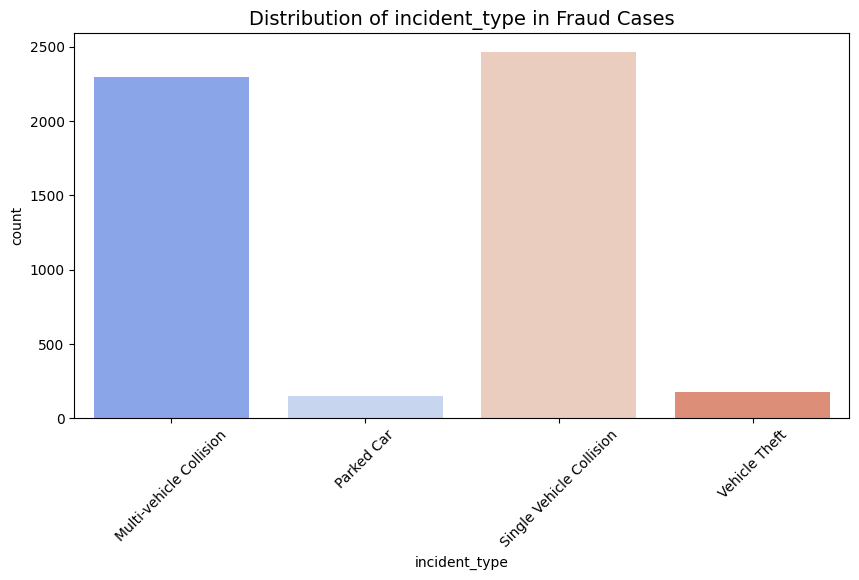

<ipython-input-32-e9b381b889a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=feature, palette='coolwarm')


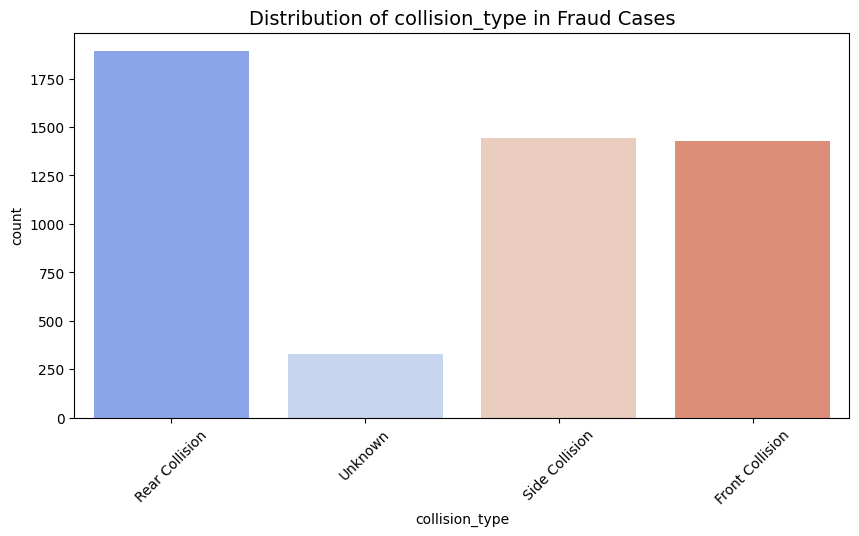

<ipython-input-32-e9b381b889a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=feature, palette='coolwarm')


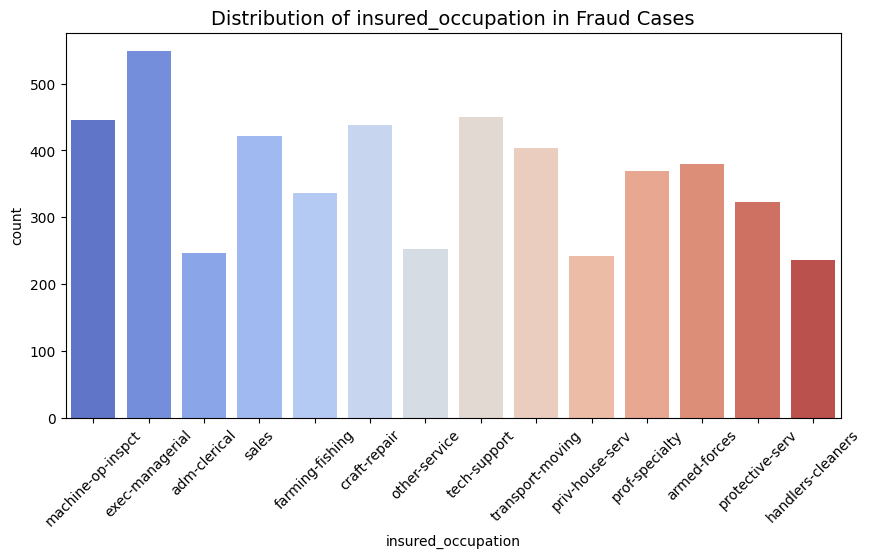

<ipython-input-32-e9b381b889a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=feature, palette='coolwarm')


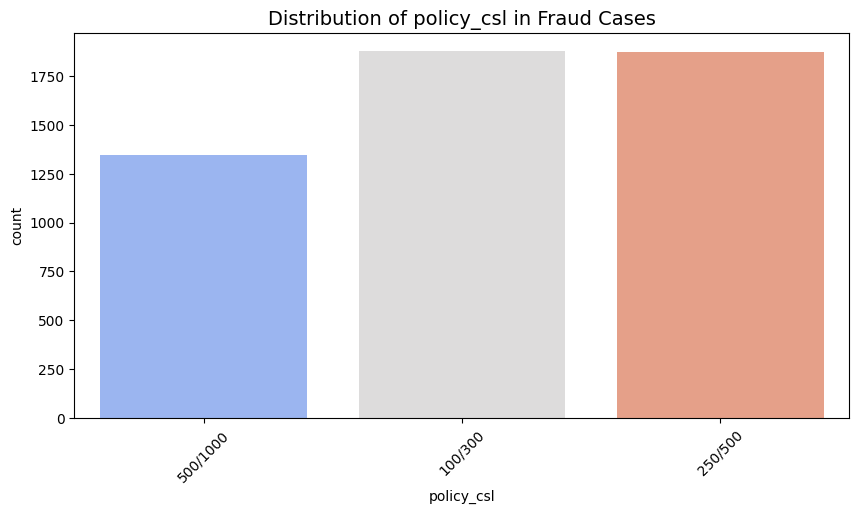

<ipython-input-32-e9b381b889a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=feature, palette='coolwarm')


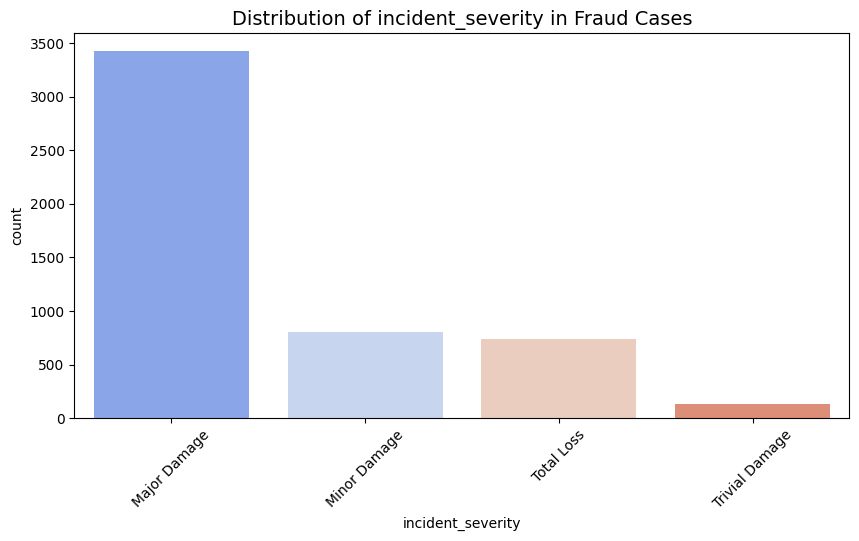

<ipython-input-32-e9b381b889a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=feature, palette='coolwarm')


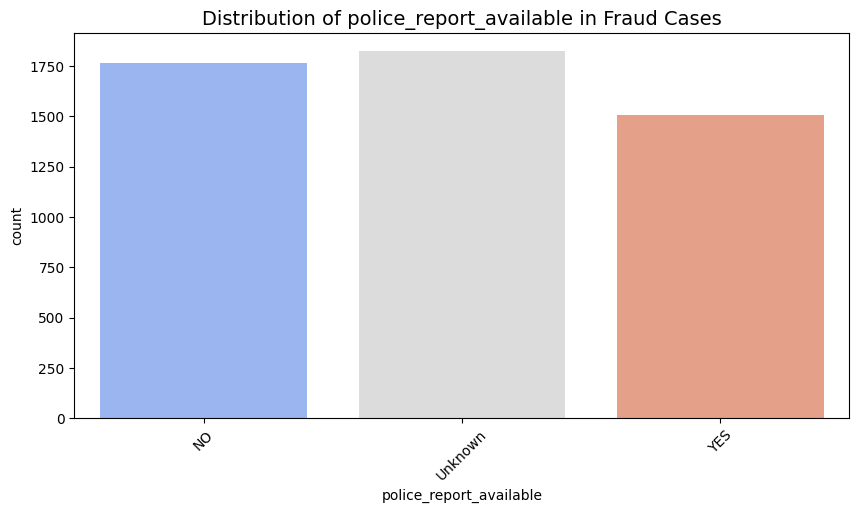

<ipython-input-32-e9b381b889a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fraud_data, x=feature, palette='coolwarm')


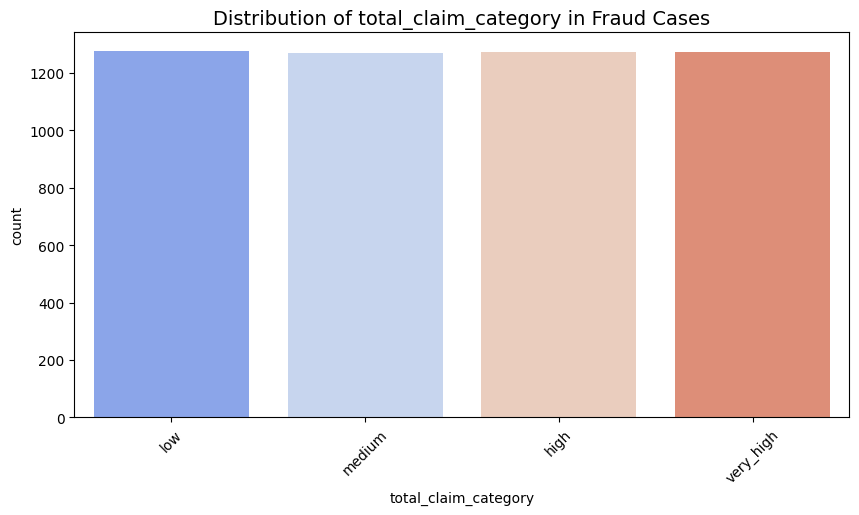

In [ ]:
def plot_feature_distribution(feature):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=fraud_data, x=feature, palette='coolwarm')
    plt.title(f'Distribution of {feature} in Fraud Cases', fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# Run for all key features
for feature in ['incident_type', 'collision_type', 'insured_occupation', 'policy_csl', 'incident_severity', 'police_report_available', 'total_claim_category']:
    plot_feature_distribution(feature)


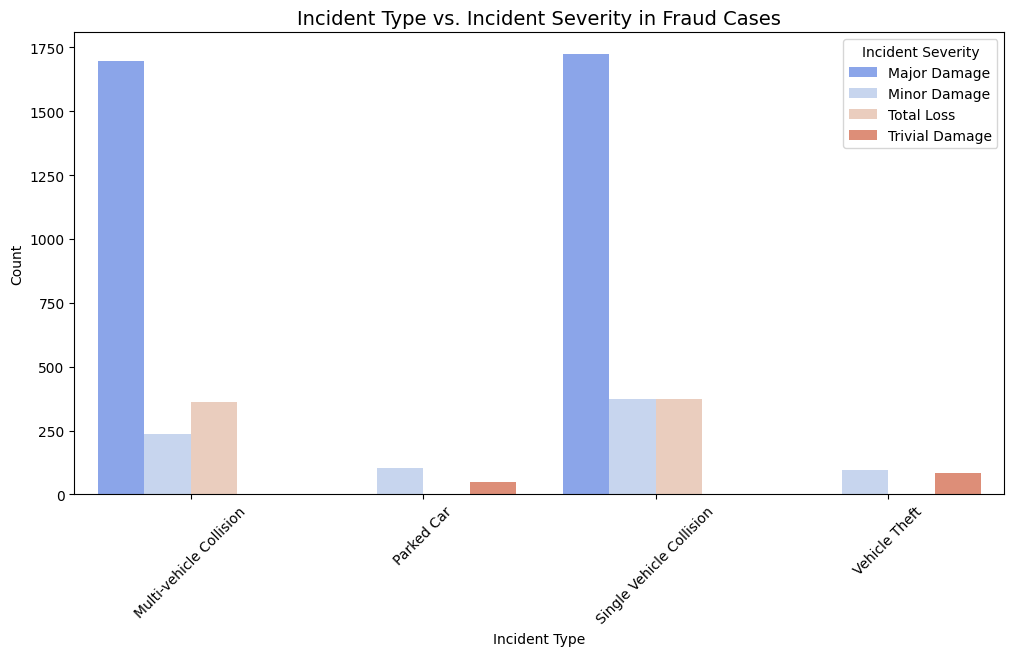

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=fraud_data, x='incident_type', hue='incident_severity', palette='coolwarm')
plt.title("Incident Type vs. Incident Severity in Fraud Cases", fontsize=14)
plt.xlabel("Incident Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Incident Severity")
plt.show()
